# Ensemble Learning
Yasir Ahmad
22MIA1064

## Random Forest

### Dataset Generation

In [1]:
import pandas as pd
import numpy as np

# Create a sample dataset with increased rows and expanded categories
np.random.seed(0)  # For reproducibility

# Generate student IDs
student_ids = range(1, 101)

# Generate skills with some correlation to chosen courses
data = {
    'Student_ID': student_ids,
    'Math_Skills': np.random.randint(50, 101, size=100),
    'Science_Skills': np.random.randint(50, 101, size=100),
    'Coding_Skills': np.random.randint(50, 101, size=100),
    'Communication_Skills': np.random.randint(50, 101, size=100),
    'Academic Background': np.random.choice(
        ['Science', 'Arts', 'Commerce', 'Engineering', 'Health', 'Humanities'],
        size=100
    )
}

# Create correlations based on chosen courses
chosen_courses = []
for background in data['Academic Background']:
    if background == 'Science':
        chosen_courses.append(np.random.choice(['Engineering', 'Medical', 'Data Science'], p=[0.5, 0.3, 0.2]))
    elif background == 'Arts':
        chosen_courses.append(np.random.choice(['Arts', 'Fine Arts', 'Psychology'], p=[0.5, 0.3, 0.2]))
    elif background == 'Commerce':
        chosen_courses.append(np.random.choice(['Business', 'Social Sciences', 'Economics'], p=[0.6, 0.3, 0.1]))
    elif background == 'Engineering':
        chosen_courses.append(np.random.choice(['Engineering', 'Data Science'], p=[0.7, 0.3]))
    elif background == 'Health':
        chosen_courses.append(np.random.choice(['Medical', 'Psychology'], p=[0.8, 0.2]))
    else:  # Humanities
        chosen_courses.append(np.random.choice(['Social Sciences', 'Arts'], p=[0.6, 0.4]))

data['Chosen_Course'] = chosen_courses

# Generate skills
data['Skills'] = [
    "Programming, Math" if course in ['Engineering', 'Data Science'] else
    "Writing, Design" if course in ['Arts', 'Fine Arts'] else
    "Economics, Business" if course in ['Business', 'Social Sciences'] else
    "Public Speaking" if course == 'Psychology' else
    "Research, Critical Thinking" if course == 'Medical' else
    "Creative Arts"
    for course in data['Chosen_Course']
]

# Create DataFrame
df = pd.DataFrame(data)

# Print the shape of the DataFrame
print(df.shape)

# Optionally, display the first few rows to see the diversity
df.head()

(100, 8)


,Student_ID,Math_Skills,Science_Skills,Coding_Skills,Communication_Skills,Academic Background,Chosen_Course,Skills
0,1,94,98,56,79,Humanities,Social Sciences,"Economics, Business"
1,2,97,99,71,99,Commerce,Business,"Economics, Business"
2,3,50,55,81,83,Engineering,Engineering,"Programming, Math"
3,4,53,91,63,68,Humanities,Social Sciences,"Economics, Business"
4,5,53,85,57,67,Commerce,Business,"Economics, Business"


In [2]:
df.shape

(100, 8)

### Encoding the categorical cols

In [3]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
label_encoders = {}
for column in ['Academic Background', 'Skills', 'Chosen_Course']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Student_ID            100 non-null    int64
 1   Math_Skills           100 non-null    int64
 2   Science_Skills        100 non-null    int64
 3   Coding_Skills         100 non-null    int64
 4   Communication_Skills  100 non-null    int64
 5   Academic Background   100 non-null    int64
 6   Chosen_Course         100 non-null    int64
 7   Skills                100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


In [5]:
df.head()

,Student_ID,Math_Skills,Science_Skills,Coding_Skills,Communication_Skills,Academic Background,Chosen_Course,Skills
0,1,94,98,56,79,4,8,1
1,2,97,99,71,99,1,1,1
2,3,50,55,81,83,2,4,2
3,4,53,91,63,68,4,8,1
4,5,53,85,57,67,1,1,1


### Training and Testing

In [6]:
X = df.drop(columns=['Student_ID', 'Chosen_Course'])
y = df['Chosen_Course']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create a Random Forest Classifier
# Create a Random Forest Classifier with optimized parameters
model = RandomForestClassifier(
    n_estimators=500,  # Increased number of trees
    max_depth=10,  # Limit tree depth to prevent overfitting
    min_samples_split=5,  # Minimum samples required to split a node
    random_state=42
)

model

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=500,
                       random_state=42)

In [9]:
# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8


In [10]:
# prompt: give code for other metrics

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Calculate precision
precision = precision_score(y_test, y_pred, average='weighted')  # 'weighted' for multi-class
print(f"Precision: {precision}")

# Calculate recall
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall}")

# Calculate F1-score
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score: {f1}")

# Generate a classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Generate a confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Precision: 0.7333333333333334
Recall: 0.8
F1-Score: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       0.00      0.00      0.00         2
           4       0.33      1.00      0.50         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2

    accuracy                           0.80        10
   macro avg       0.72      0.83      0.75        10
weighted avg       0.73      0.80      0.75        10


Confusion Matrix:
 [[2 0 0 0 0 0]
 [0 0 2 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 2 0]
 [0 0 0 0 0 2]]


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:13

### Visualiztion of metrics

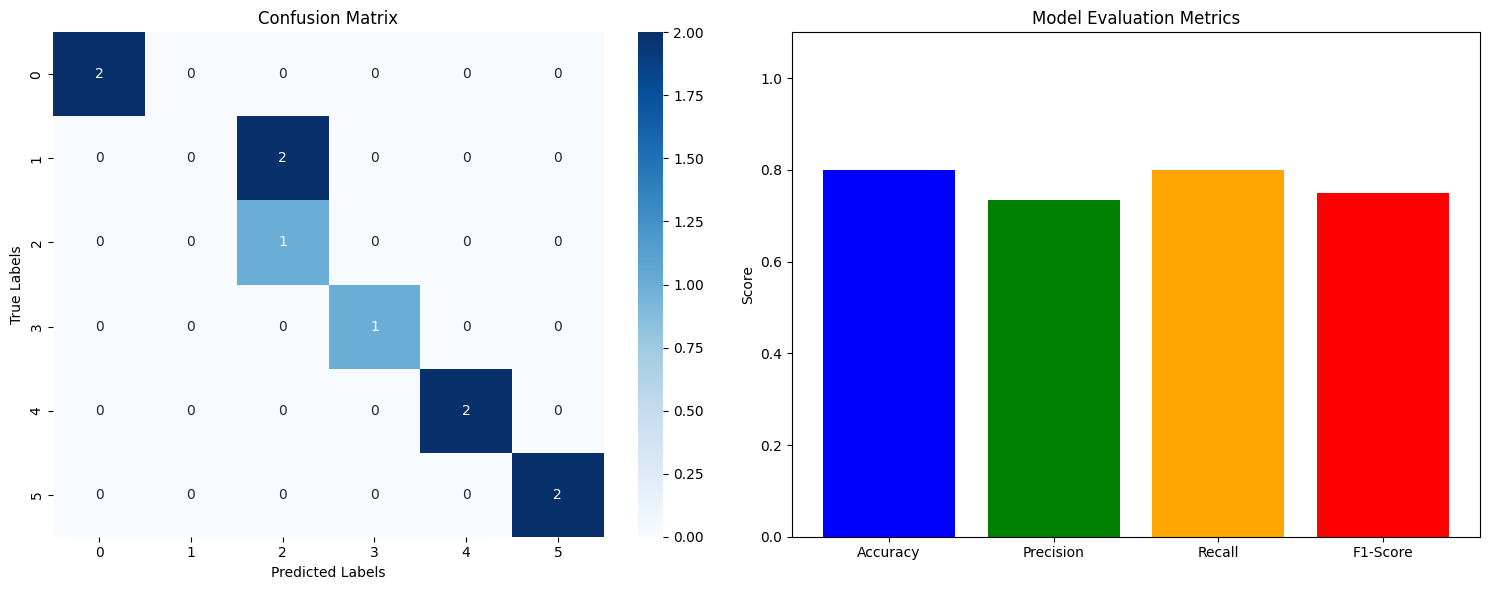

In [11]:
# prompt: make the above plot side by side

import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your existing code for model training and evaluation) ...

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot the confusion matrix on the left subplot
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

# Visualize the accuracy, precision, recall, and F1-score on the right subplot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]

axes[1].bar(metrics, scores, color=['blue', 'green', 'orange', 'red'])
axes[1].set_title('Model Evaluation Metrics')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


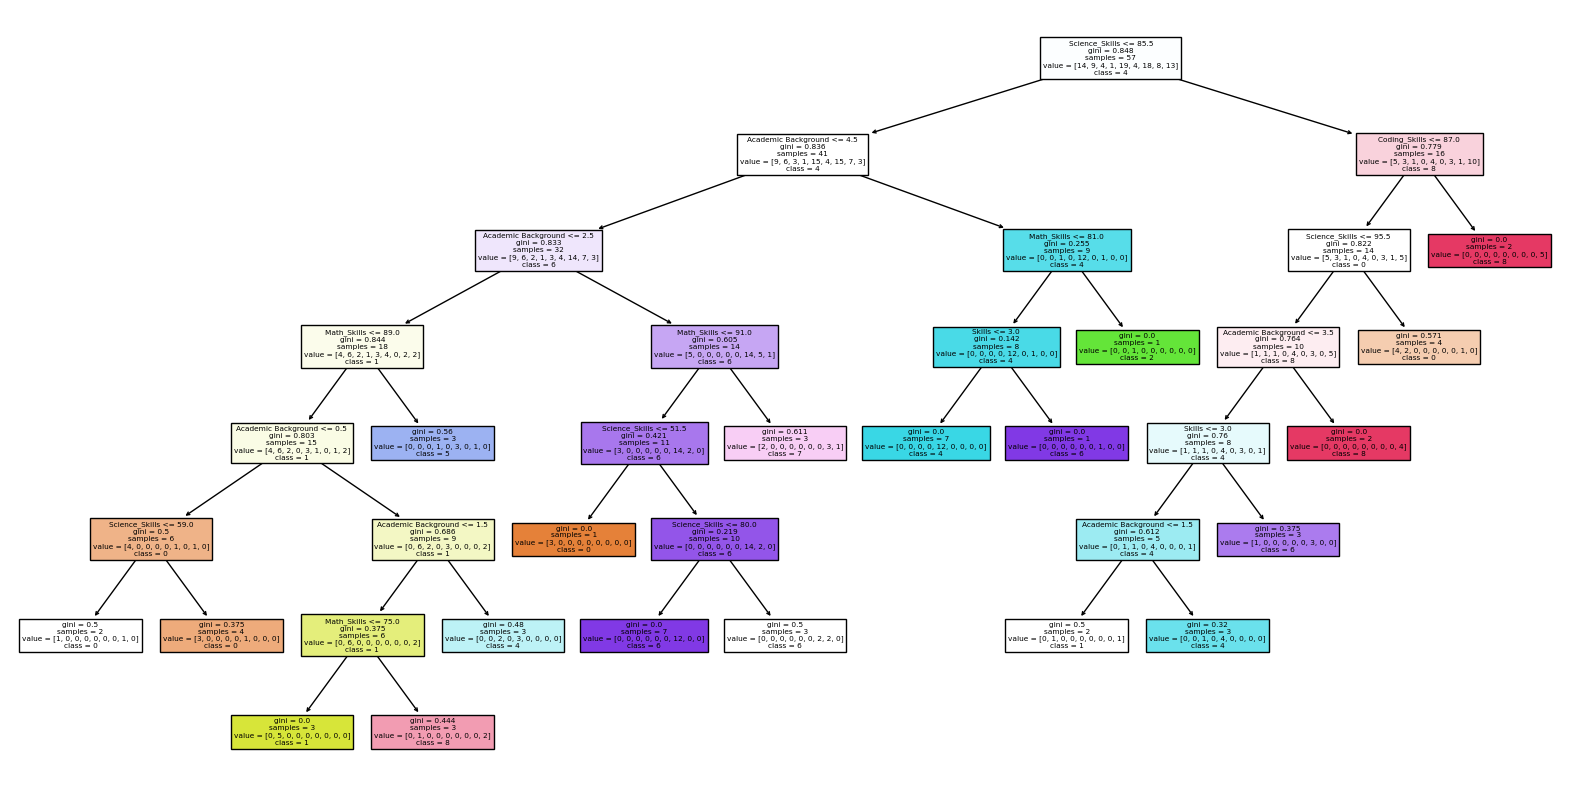

In [12]:

import numpy as np
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_index = 0
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[tree_index], feature_names=X.columns, class_names=[str(i) for i in range(len(np.unique(y)))], filled=True)
plt.show()


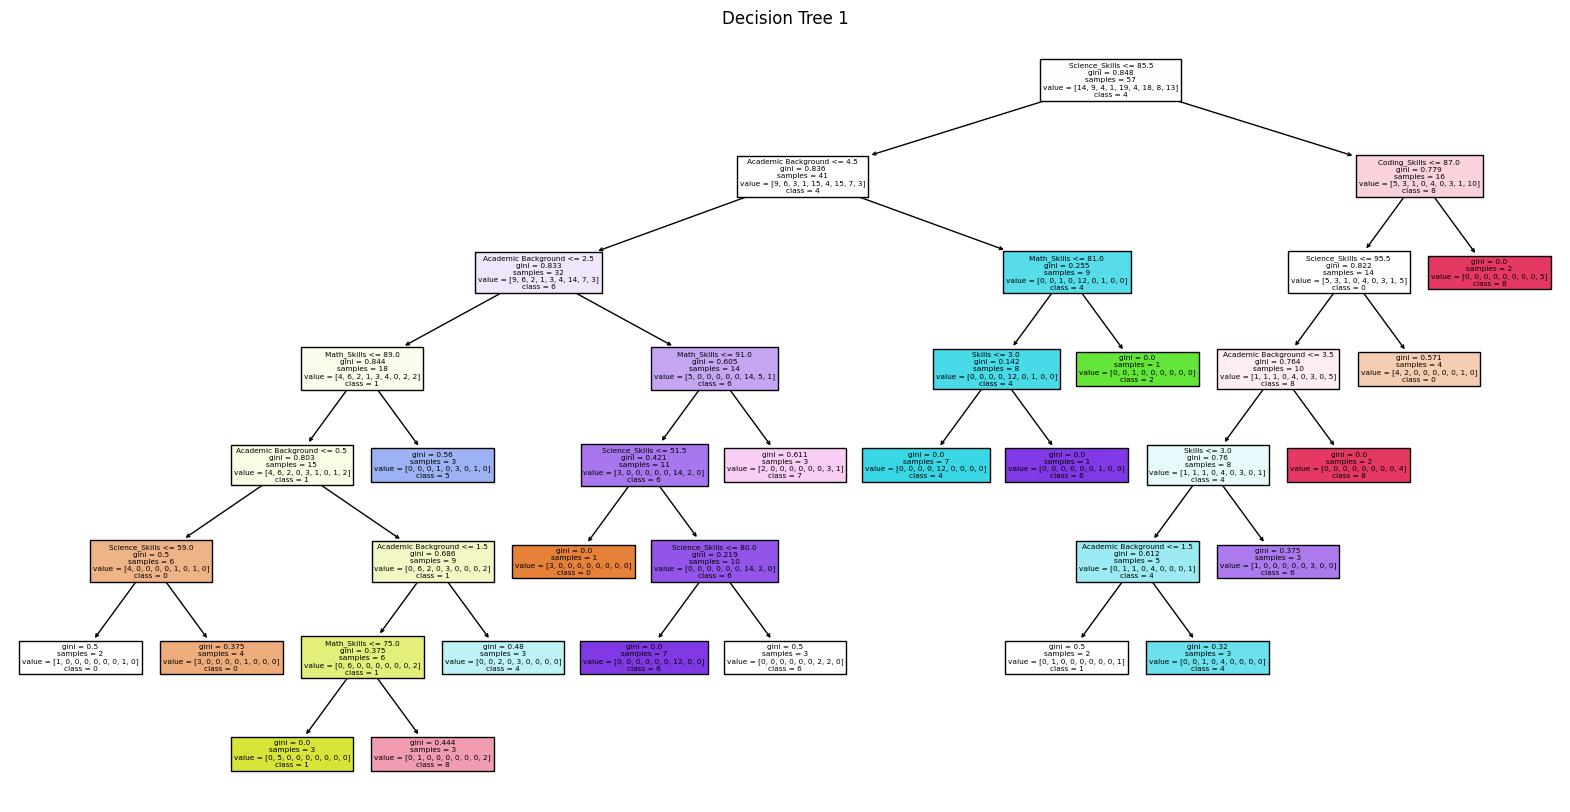

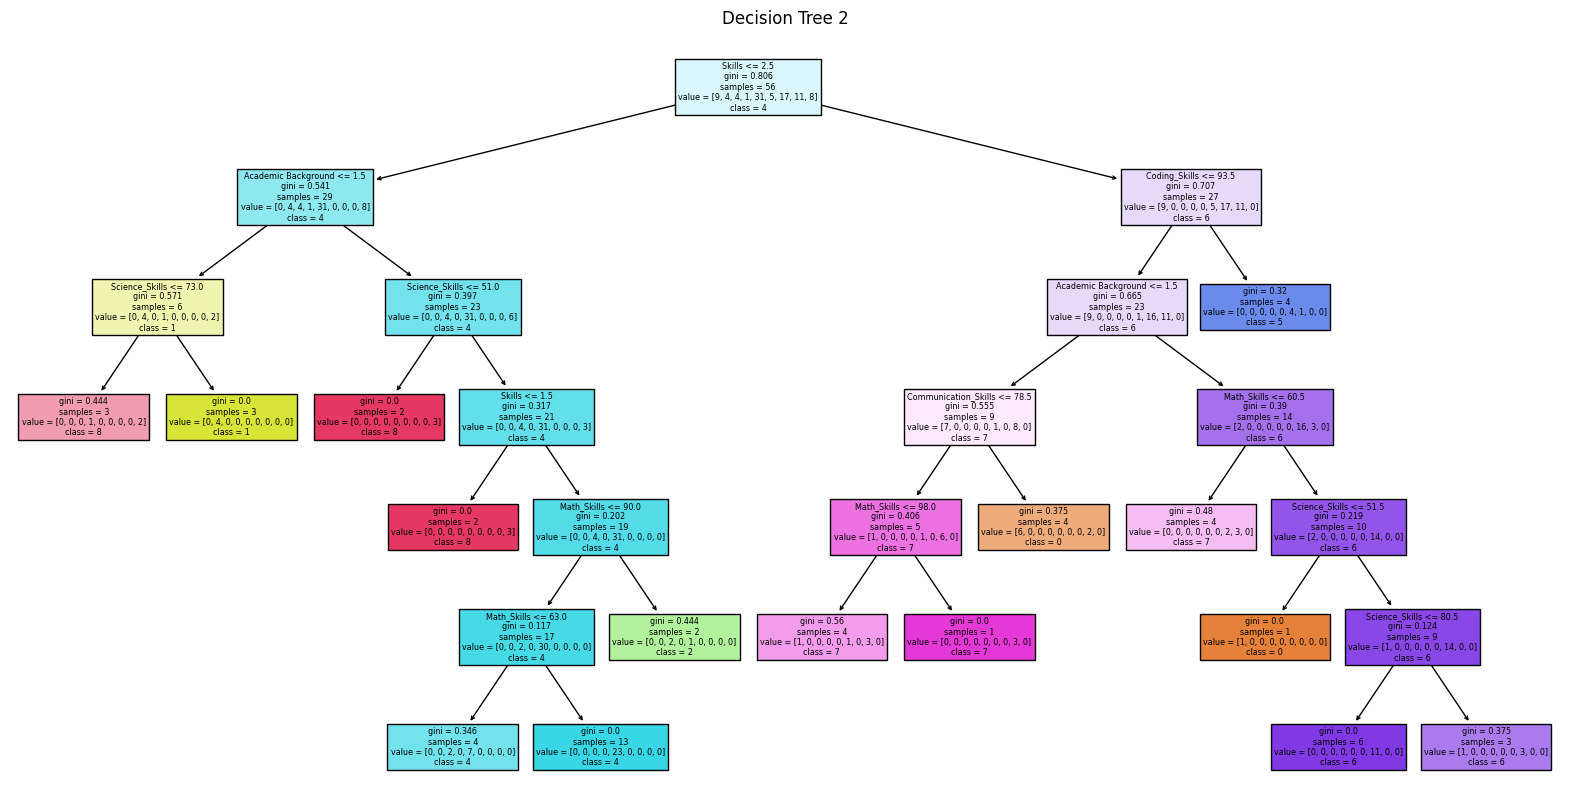

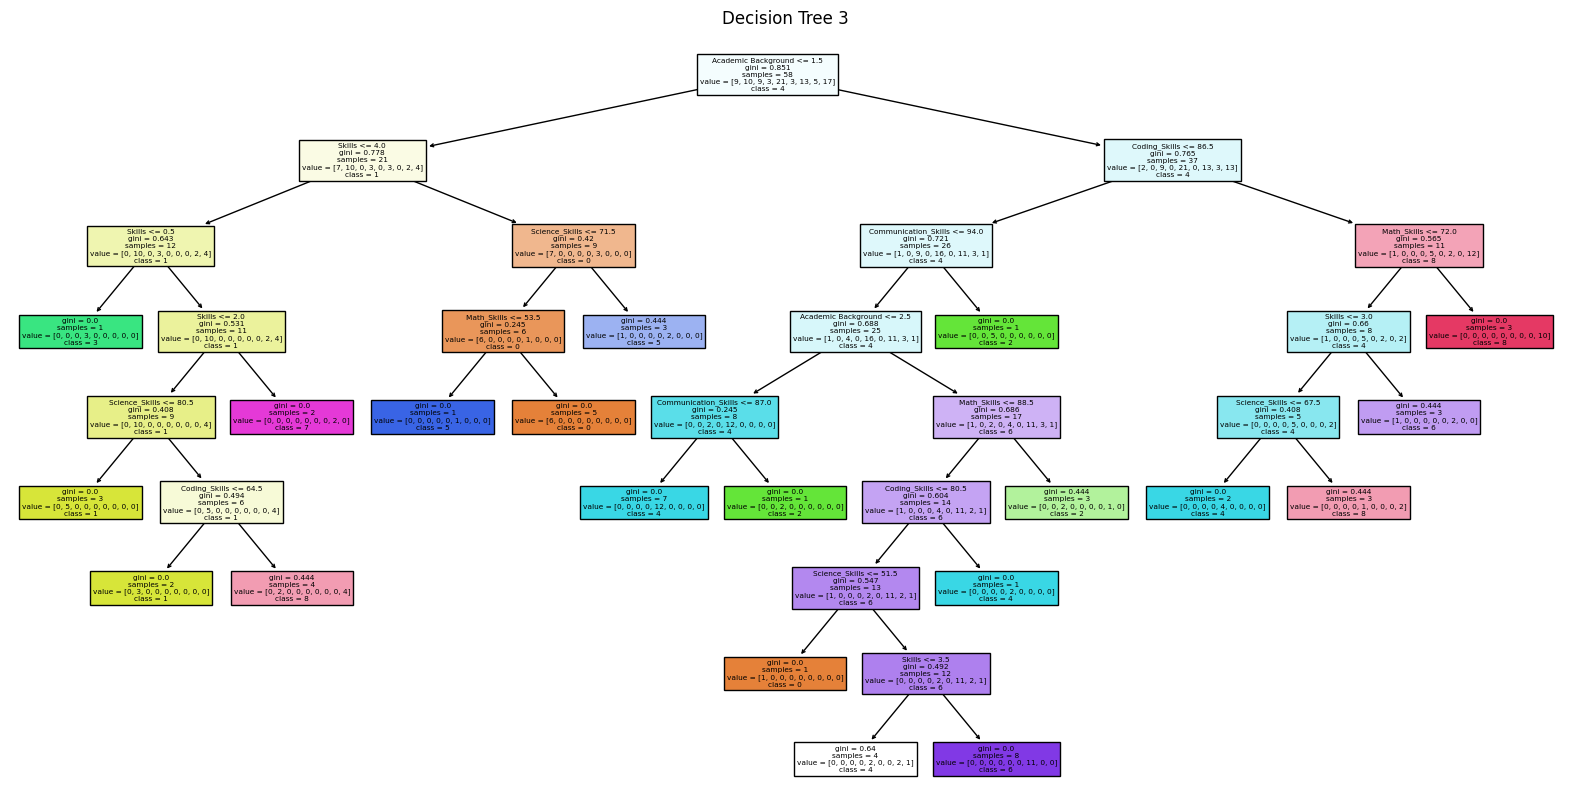

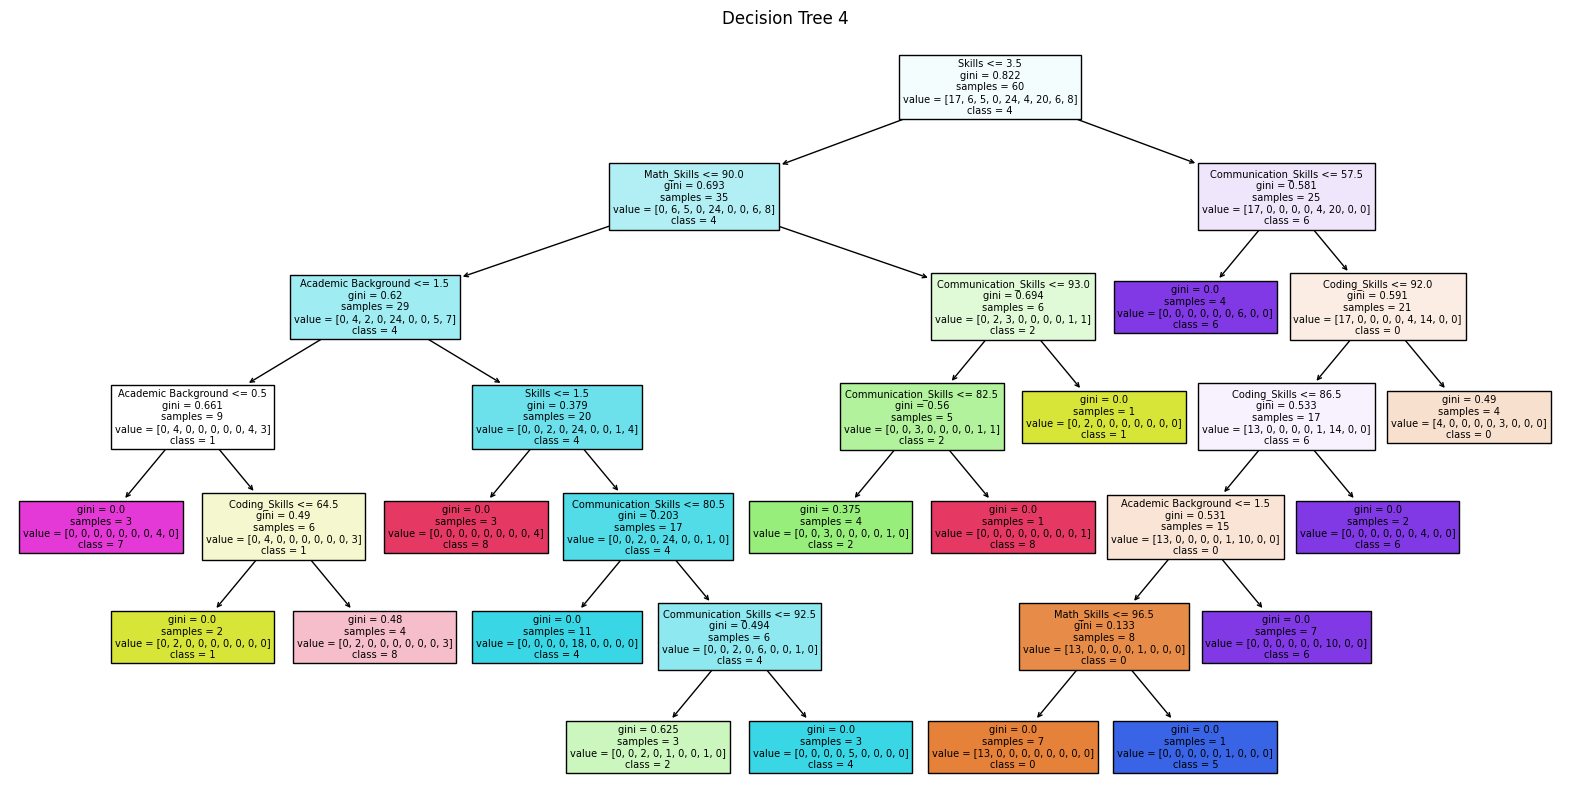

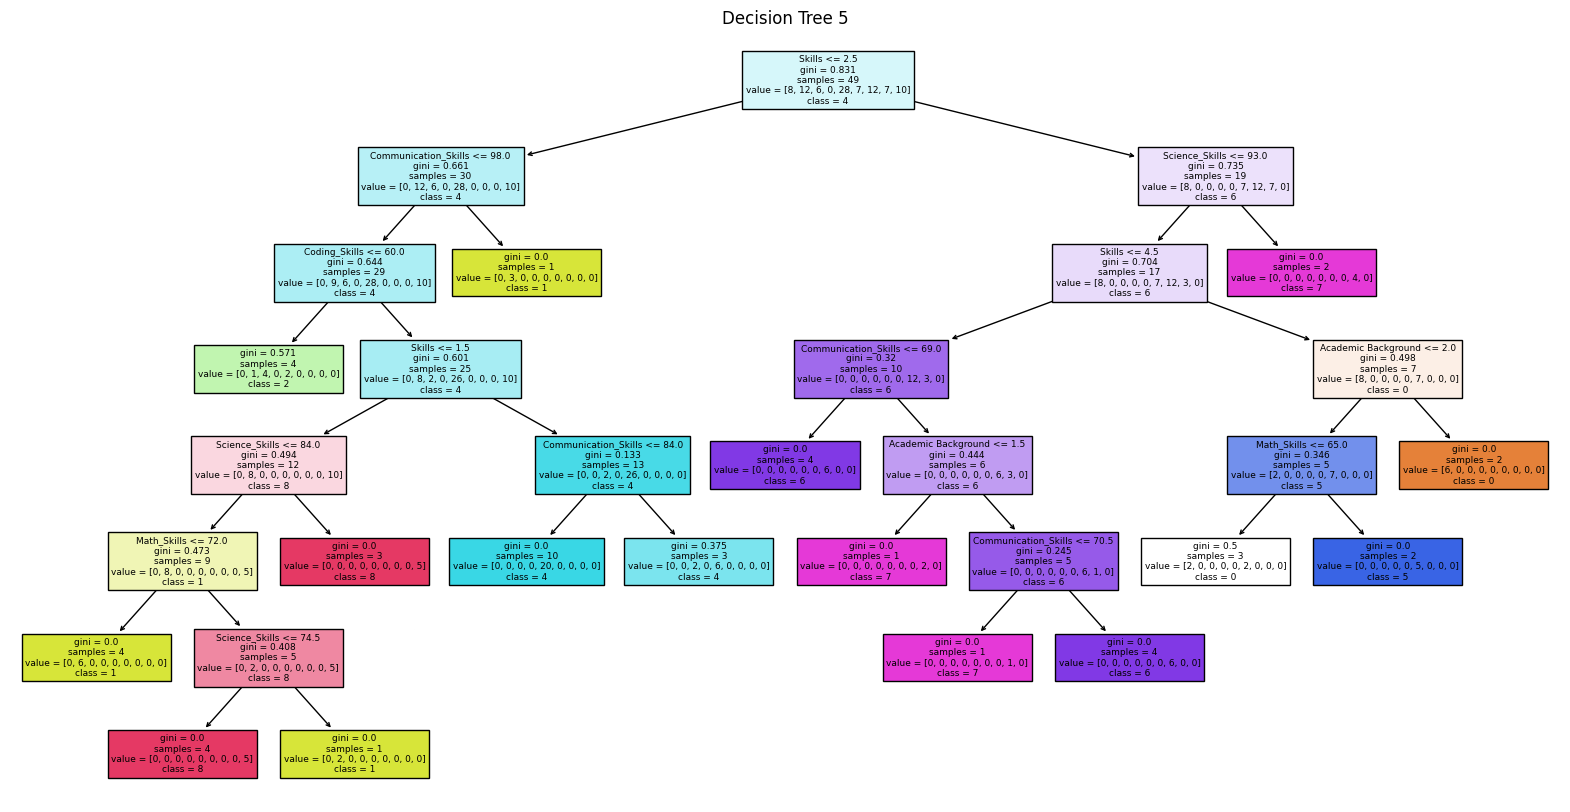

In [13]:
# prompt: visualize few trees from random forest

import matplotlib.pyplot as plt
import numpy as np
# Visualize a few trees from the random forest
num_trees_to_visualize = 5  # You can change this to visualize more or fewer trees

for i in range(num_trees_to_visualize):
    plt.figure(figsize=(20, 10))
    plot_tree(model.estimators_[i], feature_names=X.columns,
              class_names=[str(c) for c in np.unique(y)],
              filled=True)
    plt.title(f"Decision Tree {i+1}")
    plt.show()


## AdaBoost

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Train the AdaBoost model
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

# Make predictions
y_pred = ada_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           2       0.00      0.00      0.00         2
           4       0.20      1.00      0.33         1
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           8       0.00      0.00      0.00         2

    accuracy                           0.50        10
   macro avg       0.31      0.50      0.36        10
weighted avg       0.35      0.50      0.39        10



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


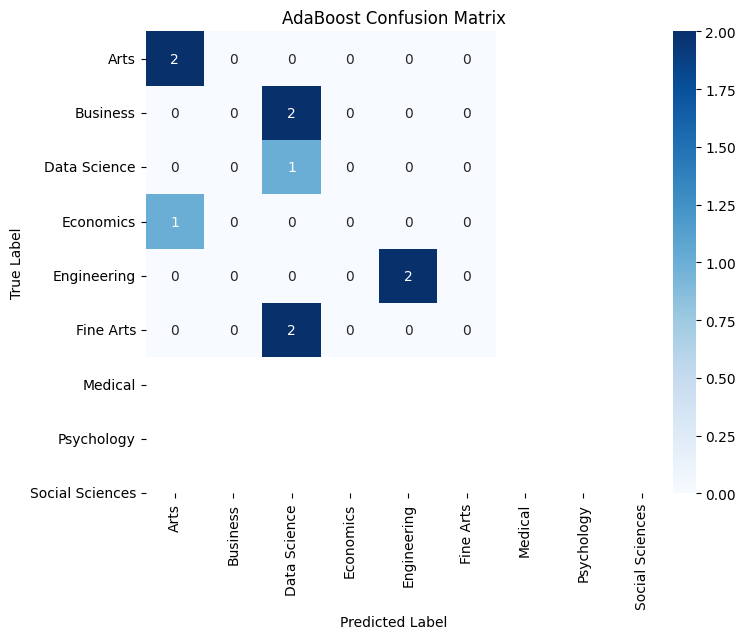

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained your AdaBoost model and have y_test and y_pred

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoders['Chosen_Course'].classes_, yticklabels=label_encoders['Chosen_Course'].classes_)
plt.title('AdaBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# You can also visualize feature importance if you want
# feature_importances = ada_model.feature_importances_
# features = X_train.columns
# plt.figure(figsize=(10, 6))
# sns.barplot(x=feature_importances, y=features)
# plt.title('AdaBoost Feature Importances')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.show()


                Feature  Importance
5                Skills    0.419409
4   Academic Background    0.221722
2         Coding_Skills    0.104372
0           Math_Skills    0.102345
3  Communication_Skills    0.083626
1        Science_Skills    0.068525


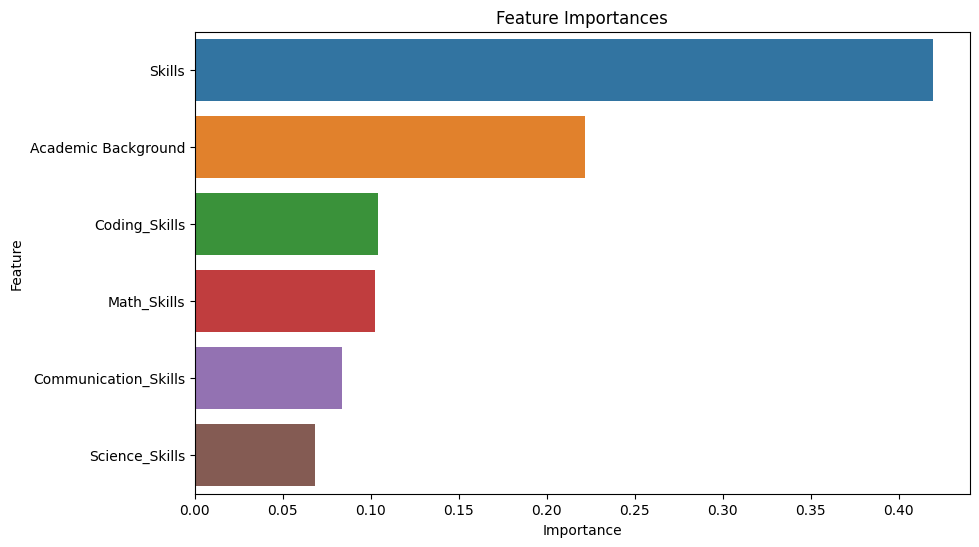

In [16]:
# prompt: give code to see the changes done by model after training

import pandas as pd
import matplotlib.pyplot as plt
# Get the feature importances from the trained Random Forest model
feature_importances = model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Print the feature importances
print(feature_importance_df)

# You can also visualize the feature importances using a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


## XGBoost

Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           2       0.00      0.00      0.00         2
           4       0.33      1.00      0.50         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2

    accuracy                           0.80        10
   macro avg       0.72      0.83      0.75        10
weighted avg       0.73      0.80      0.75        10



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


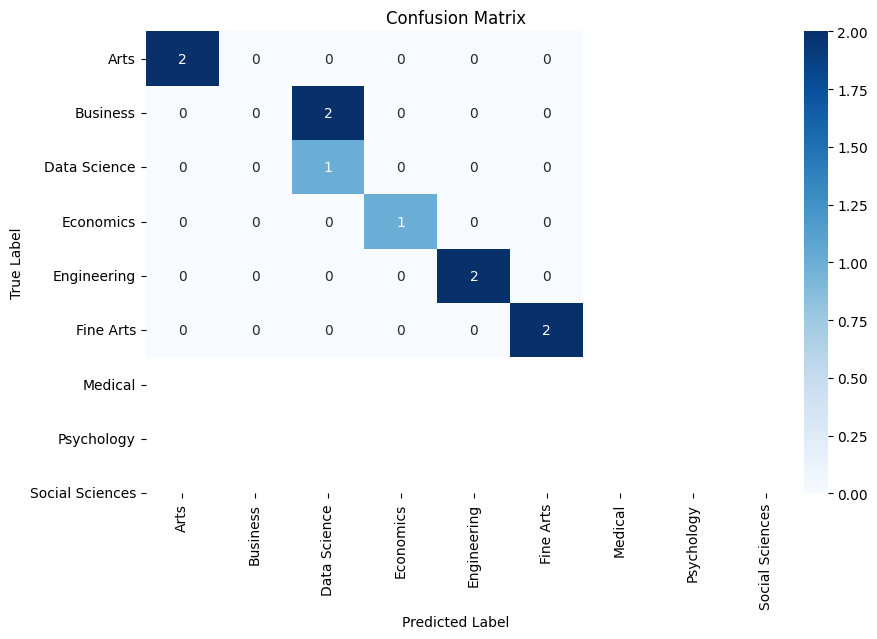

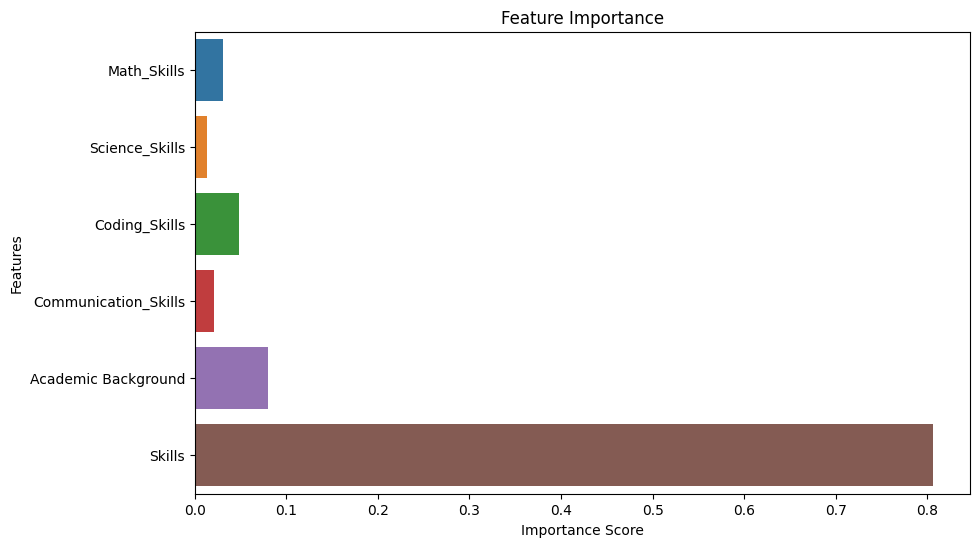

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Train the XGBoost model
xgb_model = XGBClassifier(n_estimators = 100,use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)


# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoders['Chosen_Course'].classes_,
            yticklabels=label_encoders['Chosen_Course'].classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_model.feature_importances_, y=X.columns)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


<Figure size 2000x2000 with 0 Axes>

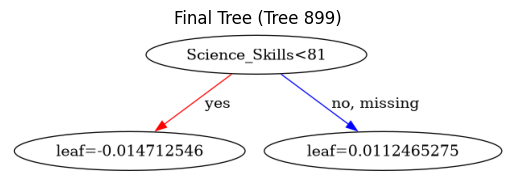

In [18]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get the total number of trees
num_trees = xgb_model.get_booster().trees_to_dataframe()['Tree'].nunique()

# Plot the final tree
plt.figure(figsize=(20, 20))
xgb.plot_tree(xgb_model, num_trees=num_trees-1)  # Last tree is at index num_trees-1
plt.title(f'Final Tree (Tree {num_trees-1})')
plt.show()


<Figure size 2000x2000 with 0 Axes>

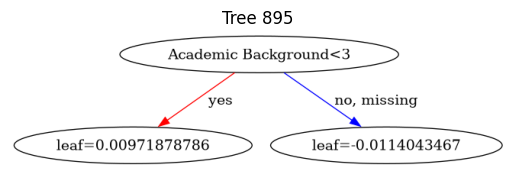

<Figure size 2000x2000 with 0 Axes>

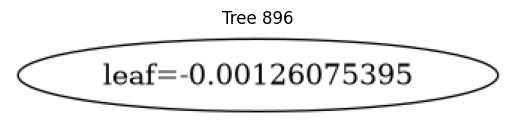

<Figure size 2000x2000 with 0 Axes>

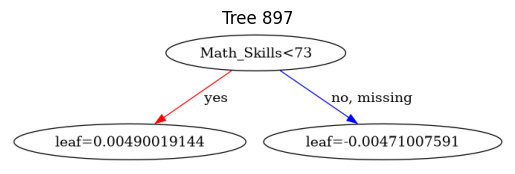

<Figure size 2000x2000 with 0 Axes>

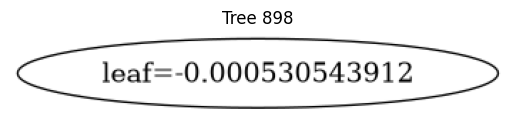

<Figure size 2000x2000 with 0 Axes>

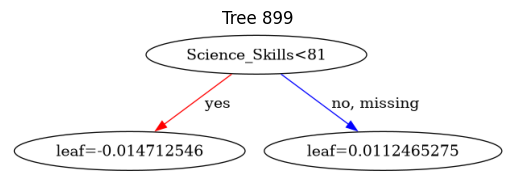

In [19]:
# Plot the last 5 trees
for i in range(num_trees-5, num_trees):
    plt.figure(figsize=(20, 20))
    xgb.plot_tree(xgb_model, num_trees=i)
    plt.title(f'Tree {i}')
    plt.show()
